## Detekcija Spam SMS poruka: Poređenje klasičnog ML, Zero-shot i Few-shot pristupa

**Predmet:** Napredna analiza podataka

**Mentor:** prof. dr Jelena Jovanović

U ovom radu bavićemo se poređenjem klasičnog machine learning pristupa klasifikaciji teksta sa zero-shot i few-shot pristupima zasnovanim na velikim jezičkim modelima (LLM), na primeru zadatka detekcije neželjenih SMS poruka (spam detekcija).

Predmet rada ovog projekta jeste binarna klasifikacija tekstualnih poruka u dvije kategorije "spam" i "ham". Spam je neželjena kategorija koja predstavlja promotivne i prevaranstske poruke. Ham predstavlja poželjnu kategoriju odnosno regularne poruke.

U ovom projektu ćemo ispitati efikasnost tradicionalnih ML metoda u odnosu na savremene LLM pristupe. Analiziraćemo razliku između zero-shot i few-shot strategije i proceniti da li dodatni kontekst (primeri u few-shot promptu) značajno poboljšava performanse modela. Dakle cilj je da se identifikuje pristup koji daje najbolje rezultate za problem spam detekcije.

U radu će se koristiti SMS Spam Collection Dataset, preuzet sa platforme Kaggle, https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset. Ovaj skup podataka je izabran jer detekcija spam poruka predstavlja realan problem u industriji. Dataset sadrži približno 5.500 SMS poruka, pri čemu svaka poruka ima:

1. tekstualni sadržaj poruke
2. oznaku klase (spam ili ham)

Podaci su isključivo tekstualne prirode, bez dodatnih numeričkih ili meta-atributa, što ih čini pogodnim za analizu i poređenje različitih pristupa klasifikaciji zasnovanih na obradi teksta.

Za poređenje ova tri pristupa koristićemo sledeće metode.

Za klasičan ML pristup koristi se TF-IDF reprezentacije teksta kako bi se tektualne poruke transformisale u numerički oblik. Na tako dobijenim numeričkim vektorima biće primenjen jedan snažniji klasifikacioni algoritam (npr. Support Vector Machine ili Logistic Regression), uz eventualno podešavanje hiperparametara radi optimizacije performansi. Ovaj model predstavlja referentnu tačku za poređenje sa LLM pristupima.

Zero-shot pristup biće realizovan korišćenjem LLM modela LLaMA 3.1 8B, dostupnog putem Groq API-ja i integrisanog kroz LangChain. Modelu se kroz pažljivo konstruisan prompt zadaje zadatak klasifikacije SMS poruka na spam ili ham, bez prethodnog davanja primera.

Few-shot pristup proširuje zero-shot strategiju uključivanjem nekoliko reprezentativnih primera u prompt.

Primeri će biti selektovani pomoću:

- text embedding modela (BAAI/bge-large-en-v1.5),
- FAISS vektorske baze,
- Max Marginal Relevance (MMR) algoritma za izbor relevantnih i međusobno raznovrsnih primera.

Cilj je da se ispita da li dinamički odabrani primeri poboljšavaju preciznost klasifikacije u odnosu na zero-shot pristup.

Performanse modela će biti procenjene korišćenjem standardnih metrika klasifikacije:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

S obzirom na to da je u problemu spam detekcije posebno važno minimizirati pogrešno označavanje legitimnih poruka kao spam (false positives), posebna pažnja biće posvećena analizi precision i recall vrednosti, dok će F1-score biti korišćen kao primarna kompozitna metrika.

Rezultati će biti interpretirani u kontekstu praktične primene spam detekcionih sistema.



In [ ]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install -q kaggle
!pip install -q scikit-learn
!pip install -q transformers==4.46.1 sentence-transformers==3.3.1
!pip install -q langchain langchain-groq groq
!pip install -q langchain-community
!pip install -q faiss-cpu FlagEmbedding langchain-huggingface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.8 MB/s eta 0:00:00


###1.  Izbor i eksploatacija dataseta
Kao što je već navedeno u uvodu projekta, koristimo SMS Spam Collection Dataset sa platforme Kaggle. Svaki primer u datasetu sadrži:
tekst poruke i binarnu oznaku klase (ham ili spam). Ovaj dataset je odličan za treniranje jezičkih modela jer sadrži realne tekstualne poruke koje zahtevaju razumevanje konteksta, namere i jezičkih obrazaca.
*Spam poruke* često sadrže: promotivne fraze ("free", "win", "claim now"),izraze hitnosti, finansijske nagrade, linkove.

To omogućava analizu koliko dobro različiti modeli prepoznaju takve obrasce.

In [ ]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_TOKEN")

In [ ]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset
!unzip -o sms-spam-collection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
sms-spam-collection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


Učitavanje i obrada podataka pomoću pandas-a

In [ ]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
label_pct = df['label'].value_counts(normalize=True) * 100
label_pct

,proportion
label,
ham,86.593683
spam,13.406317


In [ ]:
df["message_len"] = df["message"].str.len()
print(df["message_len"].describe())

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: message_len, dtype: float64


In [ ]:
print(df[df['label']=='ham']['message_len'].mean())
print(df[df['label']=='spam']['message_len'].mean())

71.02362694300518
138.8661311914324


Može se zapaziti da imamo čist nebalansiran skup podataka. Nema nedostajućih null vrednosti. Udio spam poruka je značajno manji, ham poruke čine približno 87% podataka, dok spam poruke čine samo oko 13%. Ova nebalansiranost je realistična i odražava stvarnu distribuciju u praksi, gde su većina poruka koje korisnici primaju legitimne.
Ova karakteristika je jako važna za modeliranje jer ukazuje da:
* Accuracy metrika može biti obmanjujuća (model koji uvek predviđa "ham" bi imao ~87% accuracy)
* F1-score će biti korišćen kao primarna metrika evaluacije jer je ključno smanjiti broj regularnih poruka koje su označene kao spam

Takođe iz statistike o dužini reči se vidi da je prosečna dužina poruke oko 80 karaktera. Prosečna dužina ham poruke je 71 a spam 139 pa zaključujemo da su spam poruke u proseku duže od ham što može biti koristan indikator za klasifikaciju

In [ ]:
#Podela podataka na tran i test dio
#Stratifikovana podela - održava proporciju klasa u train i test setu

from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

###2. Preprocesiranje i čišćenje teksta
Ovaj korak je neophodan kako bi se tekst normalizovao i smanjila irelevantna varijabilnost. Međutim primenjuje se minimalno čišćenje, kako bi se očuvali informativni obrasci karakteristični za spam poruke. Agresivnije metode (uklanjanje stop-reči, stemming, lematizacija) neće se primenjivati jer bi mogle da uklone signal važan za detekciju spama.

Primenjuju se sledeći koraci preprocesiranja:
- konverzija teksta u mala slova (lowercase)
- normalizacija SMS skraćenica (u→you, ur→your, r→are, itd.)
- zamena brojeva telefona generičkim tokenom PHONENUMBER
- zamena URL adresa generičkim tokenom URL
- zamena novčanih iznosa generičkim tokenom MONEY
- normalizacija razmaka

Važno je naglasiti da se pretprocesiranje primenjuje samo na klasični ML model, dok se LLM modelima prosleđuje prirodni tekst.


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    text = re.sub(r"\s+", " ", text).strip()

    text = re.sub(r'\b\d{10,}\b', ' PHONENUMBER ', text)
    text = re.sub(r'\b\d{3}[-.\s]?\d{3}[-.\s]?\d{4}\b', ' PHONENUMBER ', text)

    text = re.sub(r'£\d+[\d,]*\.?\d*', ' MONEY ', text)
    text = re.sub(r'\$\d+[\d,]*\.?\d*', ' MONEY ', text)
    text = re.sub(r'\d+p\b', ' MONEY ', text)

    abbreviations = {
      r'\bu\b': 'you',
      r'\bur\b': 'your',
      r'\br\b': 'are',
      r'\b2\b': 'to',
      r'\b4\b': 'for',
      r'\bb4\b': 'before',
      r'\btxt\b': 'text',
      r'\bmsg\b': 'message',
      r'\bpls\b': 'please',
      r'\bplz\b': 'please',
      r'\bthx\b': 'thanks',
      r'\bcuz\b': 'because',
    }
    for abbrev, full in abbreviations.items():
        text = re.sub(abbrev, full, text)
    return text


X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

###3. Ekstrakcija karakteristika pomoću TF-IDF
Klasični modeli mašinskog učenja zahtevaju numeričke ulaze.
Zbog toga se tekst konvertuje u numeričku reprezentaciju pomoću TF-IDF metode pre treniranja modela.

Dakle tekst će biti predstavljen korišćenjem TF-IDF (Term Frequency -
Inverse Document Frequency) pristupa. TF-IDF dodeljuje težinu svakoj reči na
osnovu:
- koliko često se reč pojavljuje u dokumentu (frekvencija termina),
- koliko je reč retka u celom korpusu (inverzna frekvencija dokumenta).

Ova reprezentacija ima nekoliko prednosti za detekciju spama:
- smanjuje uticaj veoma čestih reči (npr. "the", "is", "a"),
- koristi unigrame i bigrame
- ograničen broj karakteristika (npr. 5000)
- povećava težinu reči koje su informativne,
- računski je efikasna i pogodna za linearne klasifikatore.

TF-IDF je izabran kao jak i interpretativan baseline, koji omogućava fer
poređenje sa zero-shot i few-shot LLM pristupima bez uvođenja dodatnog
prethodno naučenog semantičkog znanja.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
  )
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_clean)
X_test_tfidf = tfidf_vectorizer.transform(X_test_clean)

###4. Tradicionalni ML model za klasifikaciju spam poruka
Sada će biti prikazan tradicionalan pristup mašinskog učenja na zadatku klasifikacije spam poruka. Kao ulazni podaci u klasični klasifikacioni algoritam koriste se tekstualni podaci transformisani u numeričku reprezentaciju pomoću TF-IDF metode.

Kao klasičan model izabran je **Logistic Regression** zbog
svoje jednostavnosti, interpretabilnosti i jakih performansi na
visokodimenzionalnim retkim tekstualnim reprezentacijama kao što su TF-IDF vektori. Logistička regresija se široko koristi kao standardna bazna linija u tekstualnoj klasifikaciji. Ovaj model predstavlja referentnu tačku za poređenje sa LLM pristupima.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [ ]:
# Konverzija labela u binarne vrednosti za metrike
y_train_binary = (y_train == 'spam').astype(int)
y_test_binary = (y_test == 'spam').astype(int)


In [ ]:
log_reg_model = LogisticRegression(
    max_iter=1000,           # povećan broj iteracija za konvergenciju
    random_state=42,
    class_weight='balanced', # kompenzacija nebalansiranosti
    n_jobs=-1                # koristi sve dostupne CPU jezgre
)

In [ ]:
# Treniranje modela na TF-IDF features-ima
log_reg_model.fit(X_train_tfidf, y_train_binary)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [ ]:
# Predikcija labela na test setu
y_pred = log_reg_model.predict(X_test_tfidf)

In [ ]:
# Računanje evaluacionih metrika
accuracy = accuracy_score(y_test_binary, y_pred)
precision = precision_score(y_test_binary, y_pred)
recall = recall_score(y_test_binary, y_pred)
f1 = f1_score(y_test_binary, y_pred)
accuracy, precision, recall, f1

(0.9874439461883409,
 0.9655172413793104,
 0.9395973154362416,
 0.9523809523809523)

In [ ]:
print(classification_report(y_test_binary, y_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.97      0.94      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.97      0.97      1115
weighted avg       0.99      0.99      0.99      1115



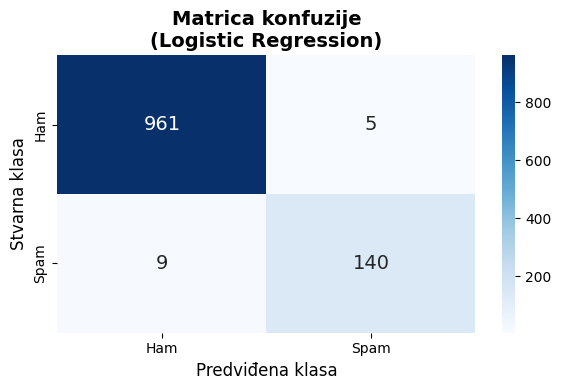

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_binary, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14})
ax.set_title('Matrica konfuzije\n(Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_ylabel('Stvarna klasa', fontsize=12)
ax.set_xlabel('Predviđena klasa', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretacija dobijenih rezultata-Tradicionalni ML model (Logistic Regression)**

U ovoj sekciji analiziramo performanse tradicionalnog pristupa mašinskog učenja zasnovanog na TF-IDF reprezentaciji features-a i Logistic Regression modelu za klasifikaciju spam poruka.

Model je treniran na train setu i evaluiran na odvojenom test setu, čime se obezbeđuje fer i nepristrasna evaluacija.

Evalucione metrike
- Accuracy : 0.99
- Precision (Spam):0.97
- Recall (Spam):0.94
- F1-score (Spam):0.95

Kako je accuracy  veoma visok znači da model tačno klasifikovao čak 99% poruka međutim u ovom slučaju to nije najvažnija metrika jer su klase nebalansirane, imamo 149 spam i 966 ham poruka. Model koji bi uvek predviđao ham bi imao 87% tačnost.

Precision  je 0.97 što znači da je od svih poruka koje je model označio kao spam 97% zaista spam. Iz matrice kofuzije vidimo da je  broj lažno pozitivnih slučajeva (FP = 5) vrlo nizak — jako malo legitimnih poruka je pogrešno filtrirano.

Recall je 0.94 dakle model uspešno prepoznaje 94% spam poruka.
Međutim, 9 spam poruka (FN) ostaje neprepoznato i dospeva do korisnika.
U kontekstu realnog sistema, ovo je najkritičnija greška, jer spam ipak stiže do krajnjeg korisnika.

F1-score predstavlja balans između precision i recall i u ovom slučaju iznosi 0.95, što ukazuje na veoma dobru ravnotežu između:
minimizovanja lažno pozitivnih slučajeva i minimizovanja propuštenih spam poruka.

Matrica konfuzije pokazuje da model pravi veoma mali broj grešaka:
- samo 5 legitimnih poruka je pogrešno označeno kao spam
- samo 9 spam poruka je propušteno

Ovi rezultati potvrđuju da klasičan ML pristup zasnovan na TF-IDF reprezentaciji i logističkoj regresiji predstavlja snažnu i konkurentnu osnovu za poređenje sa zero-shot i few-shot LLM pristupima.

###4.1 Analiza najvažnijih reči za klasifikaciju

In [ ]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = log_reg_model.coef_[0]

coef_df = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'coefficient': log_reg_model.coef_[0]
})

top_spam = coef_df.sort_values('coefficient', ascending=False).head(15)

print("\nTop 15 spam indikatora:")
for _, row in top_spam.iterrows():
    print(f"{row['feature']:20s} : {row['coefficient']:+.4f}")


Top 15 spam indikatora:
money                : +7.6181
phonenumber          : +7.1064
text                 : +5.9516
url                  : +4.5387
free                 : +3.8195
call phonenumber     : +3.6028
call                 : +3.5838
to                   : +3.4998
reply                : +3.3485
your                 : +3.2908
for                  : +2.9484
from                 : +2.7912
uk                   : +2.4566
mobile               : +2.4350
stop                 : +2.4012


Jedna od ključnih prednosti klasičnog ML pristupa je interpretabilnost. Analizom koeficijenata Logistic Regression modela možemo tačno videti koje reči najviše doprinose klasifikaciji. Primećujemo najčešće spam indikatore: reči poput "free", "call", "text", "mobile" su tipični indikatori spam poruka; tokeni MONEY i PHONENUMBER (koje smo kreirali u preprocesiranju) su snažni indikatori; bigrami poput "call phonenumber " hvataju specifične spam fraze.
Ova transparentnost je važna prednost u odnosu na LLM modele koji funkcionišu kao "crna kutija".



### 5. Zero-shot klasifikacija korišćenjem LLM
Zero-shot klasifikacija izvršava zadatak
klasifikacije bez eksplicitnog korištenja primera iz ciljnog
dataseta. Umesto učenja iz podataka specifičnih za zadatak, model se oslanja na
prethodno stečeno lingvističko i semantičko znanje dobijeno tokom obimnog
treniranja.

U kontekstu detekcije spam poruka, zero-shot pristup omogućava velikom jezičkom
modelu (LLM) da dodeljuje oznake klasa (spam ili ham) tekstualnim ulazima na
osnovu opisa zadatka na prirodnom jeziku i predefinisanog skupa kandidat-labela.

Ovaj pristup nudi nekoliko prednosti:
- eliminiše potrebu za označenim podacima za trening,
- omogućava brzu adaptaciju na nove zadatke i domene,
- značajno smanjuje vreme razvoja.

Međutim, postoje i određeni nedostaci:
- ima niže performanse u poređenju sa modelima treniranim na podacima
  specifičnim za zadatak,
- ima veliku osetljivost na formulaciju prompta i formulisanje labela,
- troši više resursa odnoso pravi veći trošak

Zero-shot klasifikacija je implementirana korišćenjem prethodno treniranog velikog jezičkog modela. Koristi se  **Meta LLaMA 3.1 8B model**, dostupan putem Groq API-ja, uz LangChain integraciju.

In [ ]:
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [ ]:
# Inicijalizacija LLM modela
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.0  # deterministički output
)

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

In [ ]:
# Kreiranje zero-shot prompta za klasifikaciju spam poruka
zero_shot_system_msg = """
You are an expert spam detection system specialized in SMS message classification.

The user will provide a list of SMS messages, each starting on a new line.

Your task:
- Carefully analyze each SMS message.
- Classify each message into one of two categories: "Spam" or "Ham".

SPAM messages typically have these characteristics:
- Offers for free prizes, money, gifts, or rewards
- Urgent calls to action: "Act now!", "Claim immediately!", "Limited time!"
- Requests to call  phonenumbers
- Suspicious links or shortened URLs
- Too-good-to-be-true claims: "You've won!", "Congratulations!"
- Requests for personal information or money

HAM (legitimate) messages typically:
- Are personal conversations between real people
- Contain meeting arrangements or coordination
- Have natural, conversational language
- Include personal updates or questions

- If unsure, assign the label "Ham".

Think carefully before making a decision.

Return your response strictly as a JSON list of tuples.
Each tuple must contain:
1. The original SMS message
2. The assigned label ("Spam" or "Ham")

Your response must contain ONLY the JSON list and nothing else.
"""

In [ ]:
zero_shot_user_msg = "SMS messages to classify:\n{messages}"

In [ ]:
#kreiranje template-a
zero_shot_template = ChatPromptTemplate.from_messages([
    ("system", zero_shot_system_msg),
    ("human", zero_shot_user_msg),
])

In [ ]:
zero_shot_chain = zero_shot_template | llm | JsonOutputParser()

In [ ]:
import numpy as np

N_SAMPLES = 68

np.random.seed(26)
sample_idx = np.random.choice(len(X_test), size=N_SAMPLES, replace=False)

X_test_sample = X_test.iloc[sample_idx].tolist()
y_test_sample = y_test.iloc[sample_idx].tolist()

sample_messages_str = "- " + "\n- ".join(X_test_sample)

In [ ]:
print(zero_shot_template.format(messages=sample_messages_str))

System: 
You are an expert spam detection system specialized in SMS message classification.

The user will provide a list of SMS messages, each starting on a new line.

Your task:
- Carefully analyze each SMS message.
- Classify each message into one of two categories: "Spam" or "Ham".

SPAM messages typically have these characteristics:
- Offers for free prizes, money, gifts, or rewards
- Urgent calls to action: "Act now!", "Claim immediately!", "Limited time!"
- Requests to call  phonenumbers
- Suspicious links or shortened URLs
- Too-good-to-be-true claims: "You've won!", "Congratulations!"
- Requests for personal information or money

HAM (legitimate) messages typically:
- Are personal conversations between real people
- Contain meeting arrangements or coordination
- Have natural, conversational language
- Include personal updates or questions

- If unsure, assign the label "Ham".

Think carefully before making a decision.

Return your response strictly as a JSON list of tuples.
Ea

In [ ]:
#pokretanje klasifikacije
zero_shot_results = zero_shot_chain.invoke({
    "messages": sample_messages_str
})

In [ ]:
for i, classified_msg in enumerate(zero_shot_results):
    msg, cls = classified_msg
    print(f"{i+1}. {cls.upper()} -> {msg[:60]}...")



1. HAM -> ÌÏ go home liao? Ask dad to pick me up at 6......
2. HAM -> K.:)do it at evening da:)urgent:...
3. HAM -> Havent shopping now lor i juz arrive only...
4. HAM -> Or ill be a little closer like at the bus stop on the same s...
5. HAM -> Now got tv 2 watch meh? U no work today?...
6. HAM -> You still at the game?...
7. HAM -> No..he joined today itself....
8. HAM -> Short But Cute: \Be a good person...
9. HAM -> Yay! You better not have told that to 5 other girls either....
10. SPAM -> I want to sent  &lt;#&gt; mesages today. Thats y. Sorry if i...
11. HAM -> Thank you. do you generally date the brothas?...
12. SPAM -> I'd like to tell you my deepest darkest fantasies. Call me 0...
13. HAM -> He is impossible to argue with and he always treats me like ...
14. HAM -> Carry on not disturbing both of you...
15. SPAM -> This message is from a great Doctor in India:-): 1) Do not d...
16. HAM -> Can you say what happen...
17. SPAM -> I'm a guy, browsin is compulsory...
18. HAM -> I kn

In [ ]:
zs_y_true = [1 if y == 'spam' else 0 for y in y_test_sample]
zs_y_pred = [1 if cls == 'Spam' else 0 for _, cls in zero_shot_results]

zs_acc = accuracy_score(zs_y_true, zs_y_pred)
zs_prec = precision_score(zs_y_true, zs_y_pred)
zs_rec = recall_score(zs_y_true, zs_y_pred)
zs_f1 = f1_score(zs_y_true, zs_y_pred)

print("\nDetailed Report:")
print(classification_report(zs_y_true, zs_y_pred, target_names=["Ham", "Spam"]))


Detailed Report:
              precision    recall  f1-score   support

         Ham       1.00      0.82      0.90        61
        Spam       0.39      1.00      0.56         7

    accuracy                           0.84        68
   macro avg       0.69      0.91      0.73        68
weighted avg       0.94      0.84      0.87        68



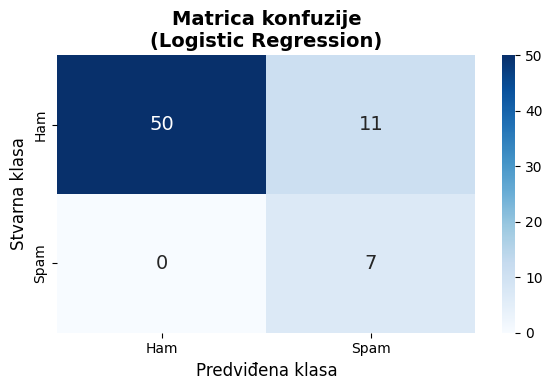

In [ ]:
# Kreiranje matrice konfuzije
cm = confusion_matrix(zs_y_true, zs_y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14})
ax.set_title('Matrica konfuzije\n(Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_ylabel('Stvarna klasa', fontsize=12)
ax.set_xlabel('Predviđena klasa', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretacija dobijenih rezultata- Zero-shot klasifikacija**

Zero-shot klasifikacija je evaluirana na nasumično izabranom podskupu od 68 test uzoraka zbog računskih troškova velikih jezičkih modela. Prompt je definisan vrlo jasno i koncizno. Dio uputsva za prepoznavanje spam i ham poruka je popravilo metrike, bez dodatka su bile accuracy: 0.75; precision: 0.29; recall: 1.0; F1: 0,45. Nakon dodavanja opisa ključnih reči za spam i ham, metrike su se popravile na accuracy: 0.84; precision: 0.39; recall: 1.0; F1: 0.56. Iako je  zero-shot model evaluiran na manjem podskupu podataka model može biti konkurentan.

Dakle dobili smo sledeće rezultate:
- Accuracy: 0.84
- Precision (spam): 0.39
- Recall (spam): 1.0
- F1-score (spam): 0.56

 Recall od 1.00 znači da model nikada ne propušta spam, ali po cenu velikog broja lažnih uzbuna (False Positives). Precision je kritično mali samo 39% poruka koje su proglašene za spam jesu zaista spam. Odnosno od svih poruka označenih kao spam, 61% su zapravo legitimne poruke (11 legitimnih poruka je klasifikovano kao spam) što može napraviti ozbiljan problem kada se posmatra realna situacija gde važne poruke ne bi stigle do korisnika.  Accuracy 84% — zavaravajuće visoka. Accuracy djeluje pristojno, ali je veoma obmanjujuća u ovom kontekstu jer je evaluirani podskup podataka izrazito neuravnotežen: 89.7% ham vs. 10.3% spam.  F1-score za Spam od 56% je nezadovoljavajući.
 F1-score kao harmonijska sredina preciznosti i odziva jasno reflektuje disbalans. Vrijednost ispod 0.60 generalno ukazuje da model nije pouzdan za produkcijsku upotrebu bez dodatnog podešavanja.


### 6. Few-shot klasifikacija korišćenjem LLM

Few-shot klasifikacija je nadogradnja zero-shot pristupa. U ovom pristupu se osim na već stečeno znanje i osnovne smernice model oslanja i na primere iz samog dataseta. Međutim iako few-shot zavisi od primera važno je imati na umu ograničenost broja primera jer previše njih može da pogorša rezultat. Zbog toga izuzetno je važno da primeri budu što kvalitetniji. Kako bi se pronašli odgovarajući primeri za prompt korišteni su sledeći algoritmi:

- **embedding model (BAAI/bge-large-en-v1.5)** za vektorsku reprezentaciju,  ovaj model dostupan je na Hugging Face Hub-u. Omogućava pretvaranje tekstova u vektorske reprezentacije i merenje semantičke sličnosti između poruka.
Dakle on pretvora SMS poruke u numeričke vektore.
- **FAISS** se koristi za skladištenje embedding vektora i brzu pretragu. Čuva embeddinge svih potencijalnih primera.
- **Max Marginal Relevance (MMR)** algoritam za izbor relevantnih i međusobno
raznovrsnih primera. Bira primere koji su semantički slični ulaznom tekstu dok
istovremeno minimizira sličnost između samih izabranih primera.

Ovaj pritup je skuplji i sporiji međutim moguće je korititi bespalten API tokene i modele.
Omogućava evaluaciju da li dinamički odabrani primeri poboljšavaju
performanse u poređenju sa zero-shot pristupom, i kako se few-shot rezultati
porede sa tradicionalnim TF-IDF + Logistic Regression baseline-om.

Zbog računskih troškova LLM inferencije, few-shot pristup je evaluiran na istom
ograničenom podskupu od 68 test uzoraka korištenom u zero-shot klasifikaciji.
Ovo obezbeđuje fer i kontrolisano poređenje između dva LLM pristupa.


In [ ]:
!pip -q install faiss-cpu

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.example_selectors.semantic_similarity import MaxMarginalRelevanceExampleSelector
from langchain_community.vectorstores.faiss import FAISS
from langchain_core.prompts.few_shot import FewShotChatMessagePromptTemplate

In [ ]:
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
# Inicijalizacija BGE embeddings modela
model_name = "BAAI/bge-large-en-v1.5"

bge_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

In [ ]:
# Priprema primera za few-shot learning
# Biramo 50 primera iz train seta (25 ham + 25 spam)

example_pool_size = 50
np.random.seed(42)

# Indeksi za svaku klasu
ham_indices = np.where(y_train == 'ham')[0]
spam_indices = np.where(y_train == 'spam')[0]

# Nasumičan izbor
selected_ham = np.random.choice(ham_indices, size=example_pool_size//2, replace=False)
selected_spam = np.random.choice(spam_indices, size=example_pool_size//2, replace=False)

# Kreiranje liste primera u formatu za LangChain
example_list = []
for idx in selected_ham:
    example_list.append({
        'message': X_train.iloc[idx],
        'classification': 'Ham'
    })
for idx in selected_spam:
    example_list.append({
        'message': X_train.iloc[idx],
        'classification': 'Spam'
    })

# Mešanje primera
np.random.shuffle(example_list)

print(f" Kreiran pool od {len(example_list)} primera za few-shot learning")
print(f"   Ham:  {sum(1 for ex in example_list if ex['classification'] == 'Ham')}")
print(f"   Spam: {sum(1 for ex in example_list if ex['classification'] == 'Spam')}")

 Kreiran pool od 50 primera za few-shot learning
   Ham:  25
   Spam: 25


In [ ]:
# Kreiranje MMR Example Selector-a
mmr_example_selector = MaxMarginalRelevanceExampleSelector.from_examples(
    examples=example_list,
    embeddings=bge_embeddings,
    vectorstore_cls=FAISS,
    k=5  # broj primera koji se biraju za svaki input
)

In [ ]:
from langchain_core.output_parsers import StrOutputParser

# Kreiranje few-shot prompt template-a
example_prompt = ChatPromptTemplate.from_messages([
    ("human", "{message}"),
    ("ai", "{classification}")
])

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_selector=mmr_example_selector,
    example_prompt=example_prompt,
    input_variables=["input"]
)

few_shot_system_msg = """You are an expert spam detector. Classify SMS messages as either "Spam" or "Ham" (legitimate).

Key spam indicators: free prizes, urgent calls to action, suspicious links/numbers, too-good-to-be-true offers.
Key ham indicators: personal conversation, natural language, meeting arrangements.

Respond with ONLY one word: "Spam" or "Ham".

Below are some example classifications:"""

final_few_shot_prompt = ChatPromptTemplate.from_messages([
    ("system", few_shot_system_msg),
    few_shot_prompt,
    ("human", "Classify this message:\n{input}")
])

few_shot_chain = final_few_shot_prompt | llm | StrOutputParser()

In [ ]:
from tqdm import tqdm
from time import sleep

# Few-shot klasifikacija na istom evaluation uzorku
# Uklanjamo poruke koje su u example pool-u (prevencija curenja podataka)

example_messages = set([ex['message'] for ex in example_list])
valid_indices = [i for i, msg in enumerate(X_test_sample) if msg not in example_messages]

X_test_fs = [X_test_sample[i] for i in valid_indices]
y_test_fs = [y_test_sample[i] for i in valid_indices]

# Funkcija za few-shot klasifikaciju
def few_shot_classify(message):
    """Klasifikuje poruku korišćenjem few-shot pristupa."""
    try:
        response = few_shot_chain.invoke({"input": message})
        result = response.strip().lower()
        if 'spam' in result:
            return 'spam'
        elif 'ham' in result:
            return 'ham'
        else:
            return 'ham'
    except Exception as e:
        print(f"Greška: {e}")
        return 'ham'

# Klasifikacija
few_shot_preds = []

for text in tqdm(X_test_fs, desc="Few-shot predikcija"):
    pred = few_shot_classify(text)
    few_shot_preds.append(pred)
    sleep(2)

Few-shot predikcija: 100%|██████████| 68/68 [03:16<00:00,  2.89s/it]


In [ ]:
# Evaluacija few-shot rezultata
fs_y_true = [1 if y == 'spam' else 0 for y in y_test_fs]
fs_y_pred = [1 if y == 'spam' else 0 for y in few_shot_preds]

fs_acc = accuracy_score(fs_y_true, fs_y_pred)
fs_prec = precision_score(fs_y_true, fs_y_pred, zero_division=0)
fs_rec = recall_score(fs_y_true, fs_y_pred, zero_division=0)
fs_f1 = f1_score(fs_y_true, fs_y_pred, zero_division=0)

fs_acc, fs_prec, fs_rec, fs_f1

(0.8970588235294118, 0.5, 0.8571428571428571, 0.631578947368421)

In [ ]:
print(classification_report(fs_y_true, fs_y_pred, target_names=['Ham', 'Spam'], zero_division=0))

              precision    recall  f1-score   support

         Ham       0.98      0.90      0.94        61
        Spam       0.50      0.86      0.63         7

    accuracy                           0.90        68
   macro avg       0.74      0.88      0.79        68
weighted avg       0.93      0.90      0.91        68



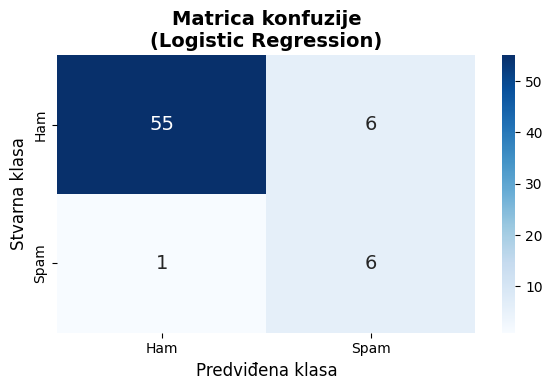

In [ ]:
# Kreiranje matrice konfuzije
cm = confusion_matrix(fs_y_true, fs_y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            annot_kws={'size': 14})
ax.set_title('Matrica konfuzije\n(Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_ylabel('Stvarna klasa', fontsize=12)
ax.set_xlabel('Predviđena klasa', fontsize=12)
plt.tight_layout()
plt.show()

**Rezultati i evaluacija**

Few-shot klasifikacija je evaluirana na istom podskupu test podataka kao i zero-shot eksperiment, kako bi se obezbedilo fer i kontrolisano poređenje.
Korištena je 25+25 few-shot konfiguracija (25 ham + 25 spam primera u pool-u).
Dinamička selekcija 5 primera za svaki input korišćenjem MMR algoritma
MMR obezbeđuje relevantne i međusobno raznovrsne primere

Dobili smo sledeće evalucione metrike:
- Accuracy: 0.89
- Precision (spam): 0.5
- Recall (spam): 0.86
- F1-score (spam): 0.63

Few-shot pristup sa MMR selekcijom primjera demonstrira statistički i praktično značajno poboljšanje u odnosu na zero-shot klasifikaciju. Accuracy je porasla sa 83.82% na 89.71%, dok je F1-score za klasu spam porastao sa 0.56 na 0.63. Najznačajnije poboljšanje je u redukciji lažno pozitivnih klasifikacija sa 11 na 6 (smanjenje od 45%), što znači da je model sa dinamički odabranim primjerima naučio preciznije razlikovati legitimne poruke od spama. Iako je recall za spam pao sa 100% na 85.71% (jedna propuštena spam poruka), ovaj trade-off rezultira ukupno balansiranim i pouzdanijim klasifikatorom. Rezultati potvrđuju da prompt sa semantički relevantnim primjerima značajno poboljšava sposobnost LLM-a za klasifikaciju u domenski specifičnim zadacima.

### 7. Evaluacija i poređenje modela

Sada ćemo sistematski uporediti performanse svih implementiranih pristupa
klasifikaciji spam poruka. Cilj ovog poređenja je evaluacija kompromisa između
tradicionalnih modela mašinskog učenja i modernih pristupa zasnovanih na velikim jezičkim modelima (LLM). Ove pristupe poredimo po različitim kriterijumima, ispitujemo njihove prediktivne performanse, potrebu za podacima, troškove resursa  i praktičnu upotrebljivost.

Evaluirani su sledeći modeli:
- TF-IDF + Logistic Regression (nadgledani baseline)
- Zero-shot LLM klasifikacija korišćenjem LLaMA 3.1 8B
- Few-shot LLM klasifikacija korišćenjem MMR selekcije + LLaMA 3.1 8B

Da bi se obezbedila fer evaluacija, svi modeli su evaluirani korišćenjem
standardnih metrika klasifikacije, uključujući accuracy, precision, recall i
F1-score. LLM pristupi su evaluirani na nasumično izabranom podskupu od 68
test uzoraka zbog računskih ograničenja, dok je tradicionalni model evaluiran
na kompletnom test setu.

In [ ]:
# Kreiranje sumarnog DataFrame-a sa svim rezultatima

# ML metrike (na celom test setu)
ml_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

# Zero-shot metrike (na uzorku)
zs_metrics = {
    'Accuracy': zs_acc,
    'Precision': zs_prec,
    'Recall': zs_rec,
    'F1-Score': zs_f1
}

# Few-shot metrike (na uzorku)
fs_metrics = {
    'Accuracy': fs_acc,
    'Precision': fs_prec,
    'Recall': fs_rec,
    'F1-Score': fs_f1
}

# Kreiranje tabele poređenja
results_df = pd.DataFrame({
    'TF-IDF + LogReg': ml_metrics,
    'Zero-shot (LLaMA)': zs_metrics,
    'Few-shot (MMR + LLaMA)': fs_metrics
})

print("=" * 70)
print("KVANTITATIVNO POREĐENJE SVIH PRISTUPA")
print("=" * 70)
print()
print(results_df.round(4).to_string())
print()

# Identifikacija najboljeg pristupa po svakoj metrici
print("\n Najbolji pristup po svakoj metrici:")
print("-" * 50)
for metric in results_df.index:
    best_model = results_df.loc[metric].idxmax()
    best_value = results_df.loc[metric].max()
    print(f"   {metric:12s}: {best_model:25s} ({best_value:.4f})")

KVANTITATIVNO POREĐENJE SVIH PRISTUPA

           TF-IDF + LogReg  Zero-shot (LLaMA)  Few-shot (MMR + LLaMA)
Accuracy            0.9874             0.8382                  0.8971
Precision           0.9655             0.3889                  0.5000
Recall              0.9396             1.0000                  0.8571
F1-Score            0.9524             0.5600                  0.6316


 Najbolji pristup po svakoj metrici:
--------------------------------------------------
   Accuracy    : TF-IDF + LogReg           (0.9874)
   Precision   : TF-IDF + LogReg           (0.9655)
   Recall      : Zero-shot (LLaMA)         (1.0000)
   F1-Score    : TF-IDF + LogReg           (0.9524)


**Tradicionalni TF-IDF + Logistic Regression** se pokazao kao najsigurniji kada je reč o prediktivnim performansama. Vodeći je po svim metrikama osim za Recall, gde vodi Zero-shot ali bez preciznosti,  izuzetno veliki F1-score 0.95 ukazuje na  	izvanredan balans — model je i precizan i osjetljiv. Takođe kada je reč o brzni obrade poruke i korištenja računarskih resursa i tu je vodeći. Za obradu jedne poruke je potrebno ~1 ms što mu daje prednost u radu sa aplikacijama sa velikim brojem poruka. Za obradu i trening može da koristi običan procesor, ne zahteva GPU ni velike količine memorije.
Mana ovog modela jeste njegova zavisnost od podataka na kojima je treniran. Za treniranje modela su potrebni jako veliki skupovi podataka koji moraju biti kvalitetno obrađeni. Ukoliko bi se promenio jezik ili domen model bi morao opet da bude treniran.
Ipak klasične metode mašinskog učenja ostaju veoma efikasne za detekciju spam poruka kada je dostupno dovoljno označenih podataka.

**Zero-shot LLM pristup** demonstrira sposobnost generalizacije bez ikakvog treniranja specifičnog za zadatak. To znači da za ovaj pristup nije potrebno skupljanje i obrada podataka što može značajno ubrzati proces klasifikacije. Prednsot u odnosu na klasični pristup je i to što model već poznaje više jezika. Iako ima najviši Recall odnosno nije propustio ni jedan spam njegov F1-score je najgori kao i Accuracy. Accuracy je gori nego kod modela koji bi uvek predviđao "ham" (zbog nebalansiranosti takav model bi imao 87% accuracy). Ovaj pristup ima najgoru preciznost pa bi  ovakav model stavio korisnika u opasnost da propusti važne poruke. Ipak njegova prednost u odnosu na Few-shot jeste to što je brži i troši manje računarskih resursa. Potrebno je manje API tokena po pozivu pa je i pristup jeftiniji.


**Few-shot LLM pristup** poboljšava performanse u odnosu na zero-shot tako što pruža kontekst kroz dinamički selektovane primere. MMR algoritam obezbeđuje da model dobija relevantne i raznovrsne primere za svaki ulaz. Za ovaj pristup potrebni su skupovi podataka ali značajno manjeg obima od onog potrebnog za klasični model mašinskog učenja. Performanse nisu loše mada ovaj pristup nije potpuno pouzdan, F1 score je 63% i preciznost je niska  pa i ovaj pristup može da uskrati korisnike za značajne poruke. Iako ima bolje performanse od Zero-shot pristupa postoje nedostaci u odnosu na njega. Model je skuplji i potrebno je više veremena za obradu poruka. Postoje API troškovi i za Groq i za embedding.

###8. Zaključak

Pre donošenja zaključka važno je imati u vidu ograničenja sa kojima sam se surela u ovom radu.
- Zero-shot i few-shot modeli su evaluirani na ograničenom podskupu
  test podataka zbog računskih ograničenja
- Few-shot performanse mogu varirati u zavisnosti od izabranih primera
  i formulacije prompta
- Nije izvršen fine-tuning LLM modela, jer je fokus bio na in-context
  učenju umesto nadgledane adaptacije

Komparativna analiza tri pristupa detekciji spama otkriva jasnu superiornost tradicionalnog TF-IDF + Logistic Regression modela u svim performansnim metrikama osim recall-a, sa F1-score-om od 0.9524 naspram 0.56 (zero-shot) i 0.63 (few-shot). Međutim, ova superiornost dolazi uz cijenu visoke zavisnosti od labeliranih podataka i ograničene fleksibilnosti pri promjeni domena. Zero-shot pristup demonstrira jedinstvenu sposobnost rada bez ikakvih podataka, ali uz neprihvatljivo nizku preciznost (38.89%). Few-shot pristup sa MMR selekcijom predstavlja srednji put — sa samo 50 labeliranih primera postiže poboljšanje od 12.8% u F1-score-u nad zero-shot pristupom. Izbor optimalnog pristupa zavisi od specifičnog konteksta primjene: dostupnosti podataka, budžeta, zahtjeva za brzinom i tolerancije na greške. Za produkcijske sisteme sa stabilnim domenom i dostupnim podacima, tradicionalni ML pristup ostaje optimalan izbor, dok LLM-bazirani pristupi nude vrijednost u scenarijima sa ograničenim podacima ili potrebom za brzom adaptacijom na nove domene.
Rezultati naglašavaju važnost izbora modela na osnovu praktičnih
ograničenja, a ne samo na osnovu performansi.